# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra las operaciones básicas para calcular el Índice de días de heladas (Frost days; FD) utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el cálculo del índice FD (Frost Days)

**M. Iturbide** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para el cálculo del índice FD (Frost Days)" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía está diseñada para ayudarte a sacar el máximo provecho de los numerosos recursos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

Concretamente, en este cuaderno/notebook calcularemos el índice de días de helada (FD, Frost Days). Para ello utilizaremos la librería de ***climate4R*** *climate4R.indices*, que, además del índice FD, permite calcular una amplia variedad de índices climáticos.

Todo el flujo de trabajo se realiza con ***climate4R***, un framework de librerías en R para la carga, el postprocesado y el análisis de datos climáticos.

<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [1]:
library(repr)
# Change plot size 
options(repr.plot.width=12, repr.plot.height=5)

### Contenido de este cuaderno:
*  [1. Carga de librerías](#1-bullet)
*  [2. Carga de datos](#2-bullet)
*  [3. Cálculo del índice y visualización](#3-bullet)

## 1 Carga de librerías <a class="anchor" id="1-bullet"></a>

Para las operaciones que se llevan a cabo en este notebook necesitaremos cuatro librerías de ***climate4R***: `loadeR` para la carga de datos, `transformeR` para calcular agregaciones temporales y extraer subconjuntos de información, `visualizeR` la representación gráfica de los resultados y `climate4R.indices` para el cálculo del índice.

In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)
library(climate4R.indices)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

climate4R.indices version 0.3.1 (2023-06-22) is loaded


Get the latest stable version (0.3.2) using <devtools::install_github('SantanderMetGroup/climate4R.indices')>

Use 'indexShow()' for an overview of the available climate indices and circIndexShow() for the circulation indices.

NOTE: use package climate4R.climdex to calculate ETCCDI indices.


Attaching package: ‘climate4R.indices’


The following object is masked from ‘package:transformeR’:

    lambWT




## 2. Carga de datos <a class="anchor" id="2-bullet"></a>


El inventario `data_inventory.csv` cataloga la lista de archivos del Almacén de datos de la PTI-Clima. Consulta `primeros_pasos_R.ipynb` para una explicación detallada.

Basta con leer este archivo mediante `read.csv` para obtener el `data.frame` que contiene esta información.

In [3]:
df <- read.csv("../../data_inventory.csv")

A continuación mostramos el cabecero del inventario.

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-5KM-regular/Iberia/day/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-IBEB-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


Para encontrar fácilmente el dataset que nos interesa, usaremos la función `subset`. Especificando `source == "ERA5-Land"` obtenemos la lista de dos datasets, uno para la Península Ibérica (*Iberia*) y otro para las Islas Canarias (*Canarias*). 

In [5]:
subset(df, source == "ERA5-Land") 

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
121,ERA5-Land_Canarias_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Canarias/day/ERA5-Land_Canarias_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic
122,ERA5-Land_Iberia_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Iberia/day/ERA5-Land_Iberia_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic


El inventario nos indica cuál es el `endpoint` de cada dataset. Es decir, el enlace que necesitamos utilizar para la carga de datos.

Primero concretamos el dataset que queremos analizar y extraemos el elemento *endpoint*. Seleccionaremos la Península Ibérica.

In [6]:
dataset <- subset(df, dataset == "ERA5-Land_Iberia_day")

In [7]:
endpoint <- dataset$endpoint

Antes de cargar los datos, conviene revisar el dataset con `dataInventory`. Esta función devuelve un resumen útil del conjunto de datos, para entender qué información contiene y cómo está descrita (variables, unidades y cobertura temporal, entre otros aspectos).

In [8]:
di <- dataInventory(endpoint)

[2026-02-11 15:46:37.350904] Doing inventory ...

[2026-02-11 15:46:37.37544] Opening dataset...

[2026-02-11 15:46:38.319832] The dataset was successfuly opened

[2026-02-11 15:46:38.450653] Retrieving info for 'sp' (6 vars remaining)

[2026-02-11 15:46:38.56295] Retrieving info for 'pr' (5 vars remaining)

[2026-02-11 15:46:38.635383] Retrieving info for 'tasmax' (4 vars remaining)

[2026-02-11 15:46:38.748248] Retrieving info for 'wss' (3 vars remaining)

[2026-02-11 15:46:38.814965] Retrieving info for 'tas' (2 vars remaining)

[2026-02-11 15:46:38.882415] Retrieving info for 'tdps' (1 vars remaining)

[2026-02-11 15:46:38.956942] Retrieving info for 'tasmin' (0 vars remaining)

[2026-02-11 15:46:39.023532] Done.



In [9]:
str(di)

List of 7
 $ sp    :List of 7
  ..$ Description: chr "Surface pressure"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 101 161
  ..$ Units      : chr "Pa"
  ..$ DataSizeMb : num 1711
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1950-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1950-01-01T00:00:00Z - 2021-12-31T00:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:101] 44 43.9 43.8 43.7 43.6 ...
  .. .. ..$ Shape      : int 101
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  .. .. ..$ Shape      : int 161
  .. .. ..$ Coordinates: chr "longitude"
 $ pr    :Li

Este resumen facilita definir la petición de carga de datos. En este ejemplo, cargamos la temperatura mínima diaria (`tasmin`). Del periodo completo disponible (véase `Date_range` en el resumen del dataset), solicitaremos un intervalo de 40 años. La carga se realiza con la función `loadGridData`, que permite especificar otros parámetros además de la variable y el periodo; por ejemplo, podemos seleccionar una estación concreta del año. En este caso, pedimos los meses de invierno (`c(12, 1:2)`). 

Como se observa en el resumen del dataset, las variables de temperatura están en unidades de Kelvin (K). Para obtenerla en grados centígrados (ºC) podemos realizar una transformación posterior a la carga o, alternativamente, utilizar un diccionario de armonización (en este caso, `Harmonization_dictionaries/ERA5-Land.dic`) para que los datos se devuelvan en las unidades que climate4R define como estándar. Para más detalles sobre el uso de diccionarios en la armonización de datos, consulta el notebook de primeros pasos (`primeros_pasos_R.ipynb`).

*NOTA: La operación de carga puede tardar unos minutos cuando se trata de conjuntos de datos de alta resolución*.

In [10]:
tasmin <- loadGridData(dataset = endpoint,
                           var = "tasmin",
                           season = c(12, 1:2),
                           years = 1981:2020,
                           dictionary = "../../Harmonization_dictionaries/ERA5-Land.dic"
                  )

[2026-02-11 15:46:39.41939] Defining harmonization parameters for variable "tasmin"

[2026-02-11 15:46:39.440579] Opening dataset...

[2026-02-11 15:46:39.568648] The dataset was successfuly opened

[2026-02-11 15:46:39.575009] Defining geo-location parameters

[2026-02-11 15:46:39.658589] Defining time selection parameters

[2026-02-11 15:46:39.913327] Retrieving data subset ...

[2026-02-11 15:47:02.621645] Done



El objeto resultante es lo que denominamos *grid de climate4R*. Se trata de una lista con los elementos "Variable", "Data", "xyCoords" y "Dates". Es posible extraer cada uno de estos componentes y transformarlos mediante operaciones básicas de R, sin embargo, las librerías de climate4R están diseñadas para trabajar de forma transparente con la estructura completa.

In [11]:
str(tasmin)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tasmin"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi TRUE
  ..- attr(*, "description")= chr "daily minimum temperature"
  ..- attr(*, "units")= chr "degC"
  ..- attr(*, "longname")= chr "minimum 2-m air temperature"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:3610, 1:101, 1:161] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  ..$ y: num [1:101] 34 34.1 34.2 34.3 34.4 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:3610] "1980-12-01 00:00:00 GMT" "1980-12-02 00:00:00 GMT" "1980-12-03 00:00:00 GMT" "1980-12-04 00:00:00 GMT" ...
  ..$ end  : chr [1:3610] "1980-12-01 00:00:0

## 3. Cálculo del índice y visualización <a class="anchor" id="3-bullet"></a>


Para el cálculo del índice utilizaremos la función `indexGrid` de la librería *cliamte4R.indices*. Esta librería incluye además la función `indexShow`, que muestra la lista de índices disponibles y las variables necesarias para su cálculo.

In [26]:
indexShow()

code,longname,indexfun,tn,tx,tm,pr,any,units,description
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
FD,Number_of_frost_days,tn.th,1,0,0,0,0,days,Count_of_days_when_TN<0degC
TNth,Number_of_cold_days,tn.th,1,0,0,0,0,days,Count_of_days_when_TN<THdegC
TXth,Number_of_hot_days,tx.th,0,1,0,0,0,days,Count_of_days_when_TX>THdegC
GDD,Growing_Degree_Days,gdd.th,0,0,1,0,0,degC,Accumulated_sum_of_degrees_of_and_when_TM>THdegC
MGDD,Modified_Growing_Degree_Days,mgdd.th,1,1,0,0,0,degC,Accumulated_sum_of_degrees_of_and_when_TM>THdegC
CDD,Cooling_Degree_Days,cdd.th,1,1,1,0,0,days,Count_of_days_being_TH=22degC
HDD,Heating_Degree_Days,hdd.th,1,1,1,0,0,days,Count_of_days_being_TH=15.5degC
CDDD,Modified_Cold_Degree_Days,cddd.th,1,1,0,0,0,degC,Accumulated_sum_of_degrees_of_and_when_TM<THdegC
P,Percentile,percentile,0,0,0,0,0,NA,Climate_value_or_percentile


Como podemos ver, el cálculo de **FD** requiere únicamente la **temperatura mínima (tn)** como variable de entrada, que ya hemos cargado en la sección anterior. Por lo tanto, solo queda ejecutar `indexGrid`.

El parámetro `time.resolution` permite definir la escala temporal a la que se calcula el índice; las opciones son `"month"`, `"year"` (por defecto) y `"climatology"`.

In [27]:
fd <- indexGrid(tn = tasmin, index.code = "FD", time.resolution = "year")

[2026-02-11 15:54:29.688445] th = 0 for index FD. Use index.code = 'TNth' to set a different threshold

[2026-02-11 15:54:34.3919] Calculating FD ...

[2026-02-11 15:54:41.447018] Done



Tras el cálculo se obtiene un nuevo *grid* que contiene el **número de días de helada** en los inviernos de cada año. Utilizaremos las funciones `temporalPlot` y `spatialPlot` para obtener, respectivamente, la **serie temporal media** de toda la región y el **mapa espacial** de la media climatológica del periodo completo.

pad applied on the interval: year



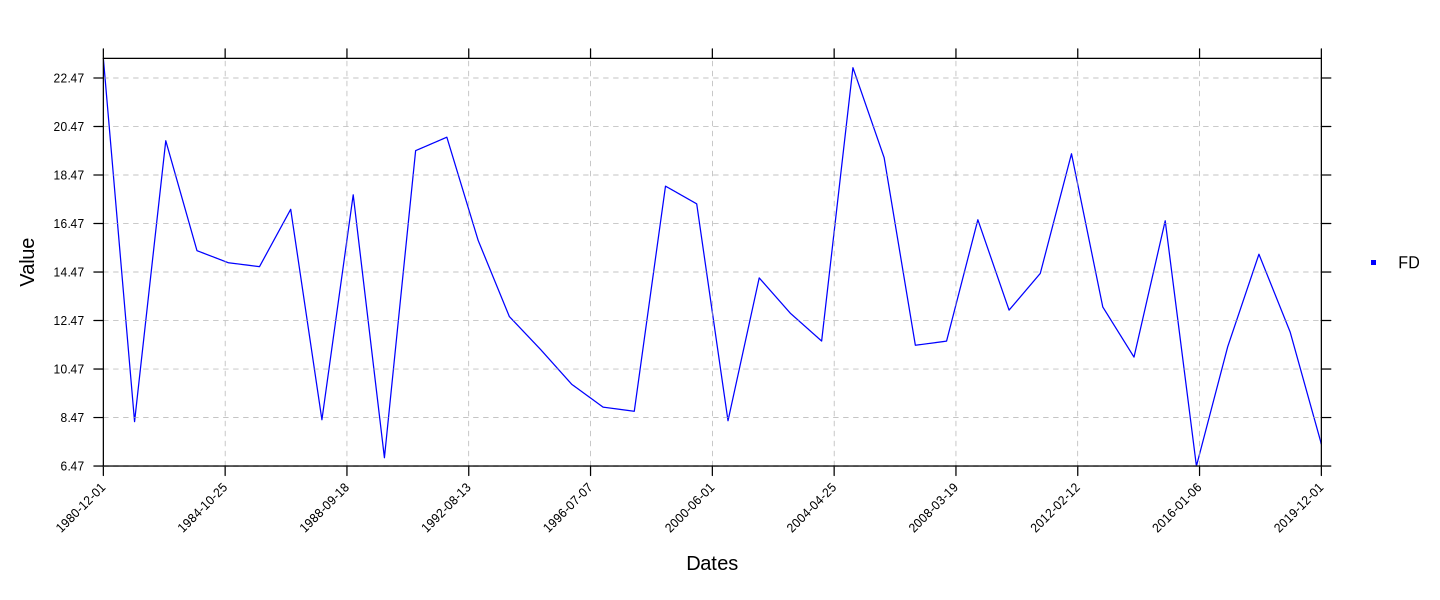

In [28]:
temporalPlot("FD" = fd, cols = "blue")

[2026-02-11 15:54:41.672006] - Computing climatology...

[2026-02-11 15:54:41.818998] - Done.



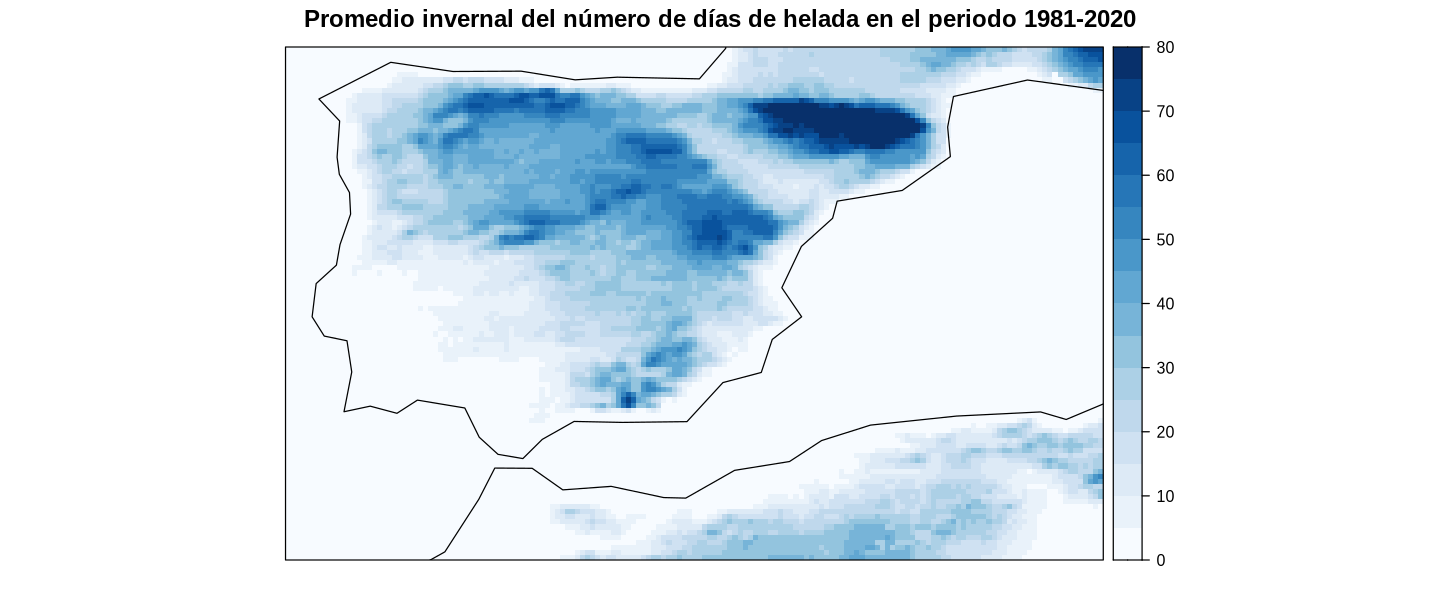

In [29]:
spatialPlot(climatology(fd), 
            at = seq(0, 80, 5),
            set.max = 80,
            set.min = 0,
            main= "Número de días de helada durante los meses de invierno en el periodo 1981-2020", 
            backdrop.theme = "coastline", 
            color.theme = "Blues")

A continuación compararemos los resultados para dos periodos temporales consecutivos (1981–2000 y 2001–2021). Para ello, generaremos los grids correspondientes con `subsetGrid` y, posteriormente, calcularemos la diferencia con `gridArithmetics`.

In [30]:
fd.1981.2000 <- subsetGrid(fd, years = 1981:2000)
fd.2001.2020 <- subsetGrid(fd, years = 2001:2020)
fd.anom <- gridArithmetics(climatology(fd.2001.2020), climatology(fd.1981.2000), operator = "-")

[2026-02-11 15:54:42.279231] - Computing climatology...

[2026-02-11 15:54:42.378753] - Done.

[2026-02-11 15:54:42.387297] - Computing climatology...

[2026-02-11 15:54:42.498744] - Done.



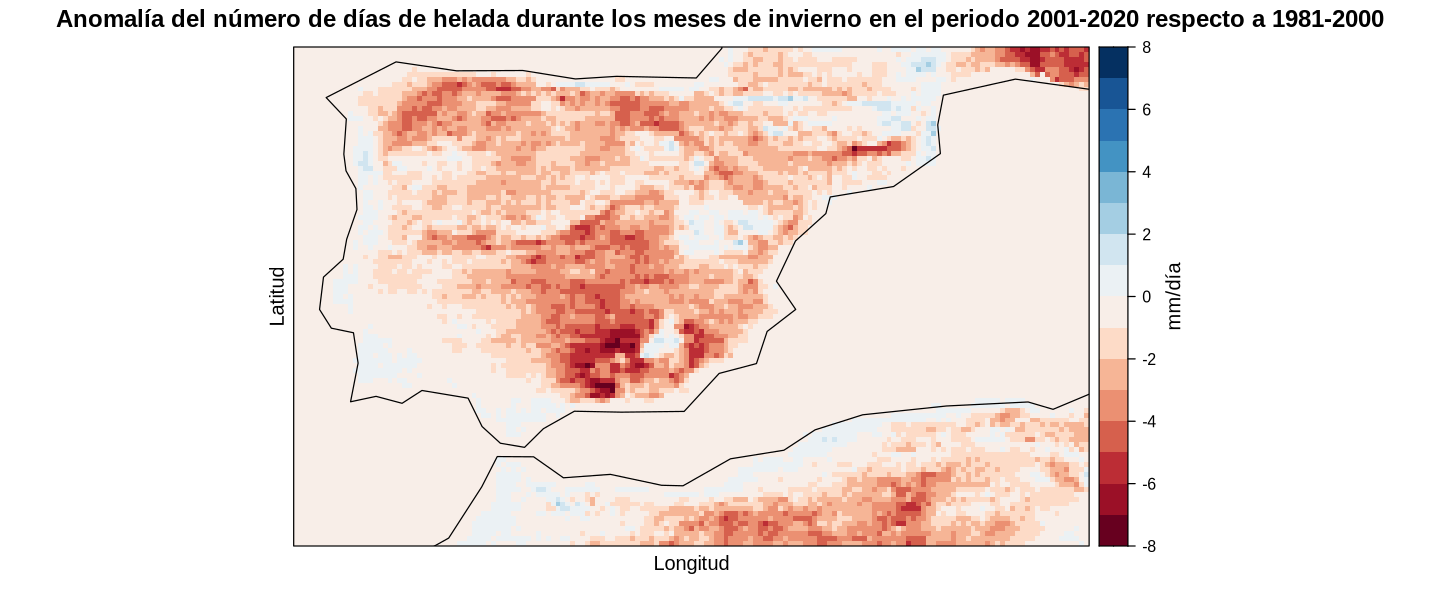

In [31]:
spatialPlot(fd.anom, 
            at = seq(-8, 8, 1),
            set.max = 8,
            set.min = -8,
            main= "Anomalía del número de días de helada durante los meses de invierno en el periodo 2001-2020 respecto a 1981-2000", 
            backdrop.theme = "coastline", 
            color.theme = "RdBu", 
            colorkey = list(space = "right",
                            title = list("mm/día", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

La Plataforma Virtual de Cálculo ofrece un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

In [32]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] climate4R.indices_0.3.1 visualizeR_1.6.4        transformeR_2.2.2      
[4] loadeR_1.8.1            climate4R.UDG_0.2.6     loadeR.java_1.1.1      
[7] rJava_1.0-11            repr_1.1.7             
